In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# EDA Bitcoin Chain Data

In [8]:
table = client.get_table("bigquery-public-data.crypto_bitcoin.blocks")
print([schema.name for schema in table.schema])

['hash', 'size', 'stripped_size', 'weight', 'number', 'version', 'merkle_root', 'timestamp', 'timestamp_month', 'nonce', 'bits', 'coinbase_param', 'transaction_count']


In [12]:
from google.cloud import bigquery

# Create client
client = bigquery.Client()

# Define the full table ID
table_id = "bigquery-public-data.crypto_bitcoin.blocks"

query = """
SELECT timestamp, bits, transaction_count
FROM bigquery-public-data.crypto_bitcoin.blocks
ORDER BY timestamp
"""

df_chain = client.query(query).to_dataframe()
# df_chain


Using Kaggle's public dataset BigQuery integration.


/usr/local/lib/python3.11/dist-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
import heapq
val = [1,2,3,4,5,6,7,8,9,10]
print(heapq.nlargest(3, val))  # [10, 9, 8]

[10, 9, 8]


: 

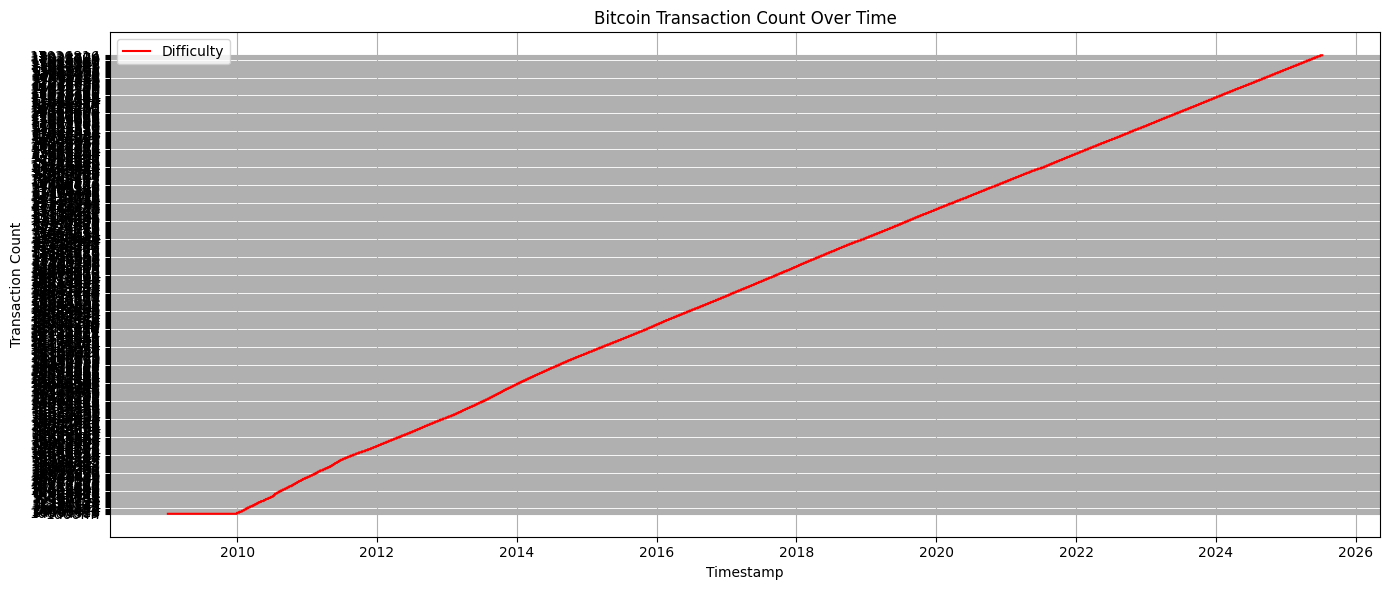

In [19]:
import matplotlib.pyplot as plt

# Convert timestamp to datetime if needed
df_chain['timestamp'] = pd.to_datetime(df_chain['timestamp'])

# Plot transaction count over time
plt.figure(figsize=(14, 6))
# plt.plot(df_chain['timestamp'], df_chain['transaction_count'], label='Transaction Count', color='blue', alpha=0.7)
plt.plot(df_chain['timestamp'], df_chain['bits'], label='Difficulty', color='red')
plt.xlabel('Timestamp')
plt.ylabel('Transaction Count')
plt.title('Bitcoin Transaction Count Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# EDA Market Data

In [49]:
df_market = pd.read_csv('/kaggle/input/bitcoin-historical-data/btcusd_1-min_data.csv')
df_market['Timestamp'] = pd.to_datetime(df_market['Timestamp'], unit='s')
# # Rename for merge clarity
df_market = df_market.rename(columns={'Timestamp': 'timestamp_minute'})
df_market['timestamp_minute'] = df_market['timestamp_minute'].dt.floor('min')

# Add UTC to df_market to match df_chain
df_market['timestamp_minute'] = df_market['timestamp_minute'].dt.tz_localize('UTC')

In [55]:
df_market.tail()

,timestamp_minute,Open,High,Low,Close,Volume
7110444,2025-07-10 00:45:00+00:00,111098.0,111138.0,111098.0,111127.0,0.880127
7110445,2025-07-10 00:46:00+00:00,111122.0,111122.0,111094.0,111094.0,0.001664
7110446,2025-07-10 00:47:00+00:00,111088.0,111105.0,111088.0,111092.0,0.050621
7110447,2025-07-10 00:48:00+00:00,111091.0,111091.0,111075.0,111080.0,0.126973
7110448,2025-07-10 00:49:00+00:00,111090.0,111109.0,111090.0,111108.0,0.016707


In [56]:
df_chain.tail()

,timestamp,bits,transaction_count,timestamp_minute
904838,2025-07-10 02:38:01+00:00,17026816,3354,2025-07-10 02:38:00+00:00
904839,2025-07-10 02:40:32+00:00,17026816,1490,2025-07-10 02:40:00+00:00
904840,2025-07-10 02:41:10+00:00,17026816,4679,2025-07-10 02:41:00+00:00
904841,2025-07-10 03:14:05+00:00,17026816,2675,2025-07-10 03:14:00+00:00
904842,2025-07-10 03:15:39+00:00,17026816,2026,2025-07-10 03:15:00+00:00


# Marged Data

For each time window between two consecutive chain data timestamps, extract and aggregate the corresponding market data as follows:

- Open: The first market price within the time window

- Close: The last market price within the time window

- High: The maximum price during the time window

- Low: The minimum price during the time window

- Transactions: The sum of all transactions in that time window

In [57]:
# Merge
df_merged = pd.merge(df_chain, df_market, on='timestamp_minute')

In [59]:
# Display merged data
df_merged.head()

,timestamp,bits,transaction_count,timestamp_minute,Open,High,Low,Close,Volume
0,2012-01-01 10:10:52+00:00,1a0e76ba,7,2012-01-01 10:10:00+00:00,4.58,4.58,4.58,4.58,0.0
1,2012-01-01 10:12:23+00:00,1a0e76ba,48,2012-01-01 10:12:00+00:00,4.58,4.58,4.58,4.58,0.0
2,2012-01-01 10:21:26+00:00,1a0e76ba,51,2012-01-01 10:21:00+00:00,4.58,4.58,4.58,4.58,0.0
3,2012-01-01 10:24:04+00:00,1a0e76ba,10,2012-01-01 10:24:00+00:00,4.58,4.58,4.58,4.58,0.0
4,2012-01-01 10:34:48+00:00,1a0e76ba,18,2012-01-01 10:34:00+00:00,4.58,4.58,4.58,4.58,0.0


In [60]:
len(df_merged)

744633

In [ ]:
# find all the ip addresses in this network
